In [1]:
# Project 4 — Global Fitness & Health Analysis
# Nav Rao | Data Analyst Portfolio

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
print("Libraries loaded successfully!")
print(f"Pandas version: {pd.__version__}")

Libraries loaded successfully!
Pandas version: 3.0.1


In [2]:
# Load the dataset
df = pd.read_csv('gym_members_exercise_tracking.csv')

# First look at the data
print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")
print(f"\nColumn names:")
print(df.columns.tolist())

Rows: 973
Columns: 15

Column names:
['Age', 'Gender', 'Weight (kg)', 'Height (m)', 'Max_BPM', 'Avg_BPM', 'Resting_BPM', 'Session_Duration (hours)', 'Calories_Burned', 'Workout_Type', 'Fat_Percentage', 'Water_Intake (liters)', 'Workout_Frequency (days/week)', 'Experience_Level', 'BMI']


In [ ]:
# See the first 5 rows 
print("=== FIRST 5 ROWS ===")
print(df.head())

# Check data types and null values 
print("\n=== DATA TYPES & NULL CHECK ===")
print(df.info())

=== FIRST 5 ROWS ===
   Age  Gender  Weight (kg)  Height (m)  Max_BPM  Avg_BPM  Resting_BPM  \
0   56    Male         88.3        1.71      180      157           60   
1   46  Female         74.9        1.53      179      151           66   
2   32  Female         68.1        1.66      167      122           54   
3   25    Male         53.2        1.70      190      164           56   
4   38    Male         46.1        1.79      188      158           68   

   Session_Duration (hours)  Calories_Burned Workout_Type  Fat_Percentage  \
0                      1.69           1313.0         Yoga            12.6   
1                      1.30            883.0         HIIT            33.9   
2                      1.11            677.0       Cardio            33.4   
3                      0.59            532.0     Strength            28.8   
4                      0.64            556.0     Strength            29.2   

   Water_Intake (liters)  Workout_Frequency (days/week)  Experience_Lev

In [4]:
# Summary statistics 
print("=== KEY STATS BY WORKOUT TYPE ===")
workout_stats = df.groupby('Workout_Type')['Calories_Burned'].agg(['mean', 'min', 'max', 'count'])
workout_stats.columns = ['Avg_Calories', 'Min_Calories', 'Max_Calories', 'Count']
workout_stats = workout_stats.round(1).sort_values('Avg_Calories', ascending=False)
print(workout_stats)

print("\n=== OVERALL DATASET STATS ===")
print(df[['Age', 'Calories_Burned', 'Session_Duration (hours)', 'BMI', 'Fat_Percentage']].describe().round(1))

=== KEY STATS BY WORKOUT TYPE ===
              Avg_Calories  Min_Calories  Max_Calories  Count
Workout_Type                                                 
HIIT                 925.8         333.0        1766.0    221
Strength             910.7         350.0        1783.0    258
Yoga                 903.2         330.0        1582.0    239
Cardio               884.5         303.0        1625.0    255

=== OVERALL DATASET STATS ===
         Age  Calories_Burned  Session_Duration (hours)    BMI  Fat_Percentage
count  973.0            973.0                     973.0  973.0           973.0
mean    38.7            905.4                       1.3   24.9            25.0
std     12.2            272.6                       0.3    6.7             6.3
min     18.0            303.0                       0.5   12.3            10.0
25%     28.0            720.0                       1.0   20.1            21.3
50%     40.0            893.0                       1.3   24.2            26.2
75%     49

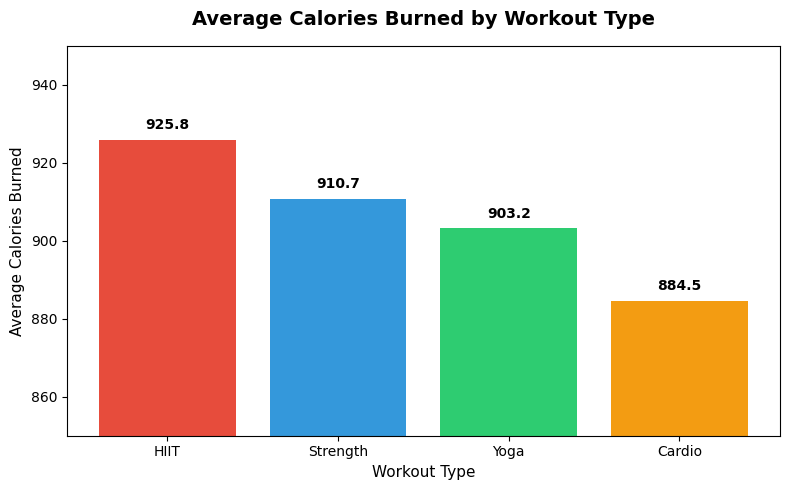

Chart saved!


In [5]:
# Bar chart — Average Calories Burned by Workout Type
fig, ax = plt.subplots(figsize=(8, 5))

colors = ['#E74C3C', '#3498DB', '#2ECC71', '#F39C12']
bars = ax.bar(workout_stats.index, workout_stats['Avg_Calories'], color=colors)

ax.set_title('Average Calories Burned by Workout Type', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Workout Type', fontsize=11)
ax.set_ylabel('Average Calories Burned', fontsize=11)
ax.set_ylim(850, 950)

# Add value labels on top of each bar
for bar, val in zip(bars, workout_stats['Avg_Calories']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
            f'{val}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.savefig('chart1_calories_by_workout.png', dpi=150)
plt.show()
print("Chart saved!")





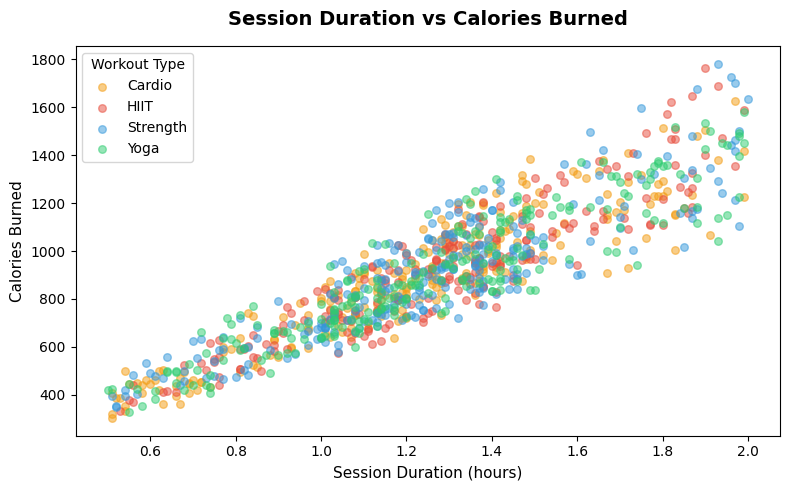

Chart saved!


In [6]:
# Scatter plot — Does longer session = more calories burned?
fig, ax = plt.subplots(figsize=(8, 5))

colors_map = {'HIIT': '#E74C3C', 'Strength': '#3498DB', 
              'Yoga': '#2ECC71', 'Cardio': '#F39C12'}

for workout, group in df.groupby('Workout_Type'):
    ax.scatter(group['Session_Duration (hours)'], 
               group['Calories_Burned'],
               label=workout, 
               color=colors_map[workout],
               alpha=0.5, s=30)

ax.set_title('Session Duration vs Calories Burned', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Session Duration (hours)', fontsize=11)
ax.set_ylabel('Calories Burned', fontsize=11)
ax.legend(title='Workout Type')

plt.tight_layout()
plt.savefig('chart2_duration_vs_calories.png', dpi=150)
plt.show()
print("Chart saved!")

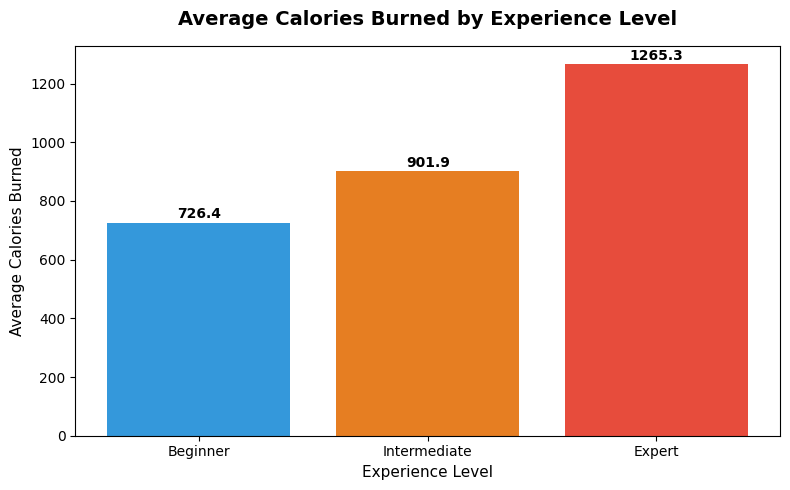

Chart saved!


In [7]:
# Bar chart — Does experience level affect calories burned?
exp_stats = df.groupby('Experience_Level')['Calories_Burned'].mean().round(1)
exp_labels = {1: 'Beginner', 2: 'Intermediate', 3: 'Expert'}
exp_stats.index = exp_stats.index.map(exp_labels)

fig, ax = plt.subplots(figsize=(8, 5))

bars = ax.bar(exp_stats.index, exp_stats.values, color=['#3498DB', '#E67E22', '#E74C3C'])

ax.set_title('Average Calories Burned by Experience Level', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Experience Level', fontsize=11)
ax.set_ylabel('Average Calories Burned', fontsize=11)

for bar, val in zip(bars, exp_stats.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
            f'{val}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.savefig('chart3_calories_by_experience.png', dpi=150)
plt.show()
print("Chart saved!")



In [8]:
# Export clean data for Tableau dashboard
df_export = df.copy()

# Add experience label column for Tableau
df_export['Experience_Label'] = df_export['Experience_Level'].map(
    {1: 'Beginner', 2: 'Intermediate', 3: 'Expert'})

# Save to CSV
df_export.to_csv('fitness_data_clean.csv', index=False)
print("Clean data exported successfully!")
print(f"Rows exported: {len(df_export)}")
print(f"Columns exported: {len(df_export.columns)}")
print(f"\nColumns: {df_export.columns.tolist()}")

Clean data exported successfully!
Rows exported: 973
Columns exported: 16

Columns: ['Age', 'Gender', 'Weight (kg)', 'Height (m)', 'Max_BPM', 'Avg_BPM', 'Resting_BPM', 'Session_Duration (hours)', 'Calories_Burned', 'Workout_Type', 'Fat_Percentage', 'Water_Intake (liters)', 'Workout_Frequency (days/week)', 'Experience_Level', 'BMI', 'Experience_Label']
